In [ ]:
!pip install pandas numpy scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [3]:
df = pd.read_csv("./AmesHousing.csv")
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


Seleccion de variables

In [4]:
df.columns

Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional',
       'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt',
      

In [5]:
columnas_seleccionadas = ["Lot Area","Overall Qual","Year Built","Year Remod/Add","Mas Vnr Area","BsmtFin SF 1","Bsmt Unf SF","Total Bsmt SF","1st Flr SF"
,"2nd Flr SF","Gr Liv Area","Full Bath","Half Bath","Bedroom AbvGr","TotRms AbvGrd","Fireplaces","Garage Cars","Garage Area"]

df_seleccionado = df[columnas_seleccionadas]

Imputar con promedio

In [8]:
imputer = SimpleImputer(strategy='mean')
df_imputado = imputer.fit_transform(df_seleccionado)

Estandarizar datos

In [9]:
scaler = StandardScaler()
df_estandarizado = scaler.fit_transform(df_imputado)

Aplicar PCA

In [10]:
pca = PCA(n_components=16)
componentes = pca.fit_transform(df_estandarizado)
df_pca = pd.DataFrame(data=componentes, columns=[f"PC{i+1}" for i in range(componentes.shape[1])])

Varianza explicada

In [11]:
varianza = pca.explained_variance_ratio_
print("Varianza explicada de cada componente:")
print(varianza)

varianza_acumulada = np.cumsum(varianza)
print("Varianza acumulada:")
print(varianza_acumulada)

Varianza explicada de cada componente:
[0.34922419 0.15181212 0.09508684 0.08793061 0.04894518 0.04694384
 0.04394311 0.03834462 0.03224548 0.02484927 0.02128056 0.0174982
 0.01429392 0.01092071 0.00867548 0.00533183]
Varianza acumulada:
[0.34922419 0.50103631 0.59612314 0.68405376 0.73299894 0.77994278
 0.82388589 0.86223051 0.89447599 0.91932526 0.94060583 0.95810403
 0.97239795 0.98331866 0.99199413 0.99732596]


Gráfico de varianza explicada

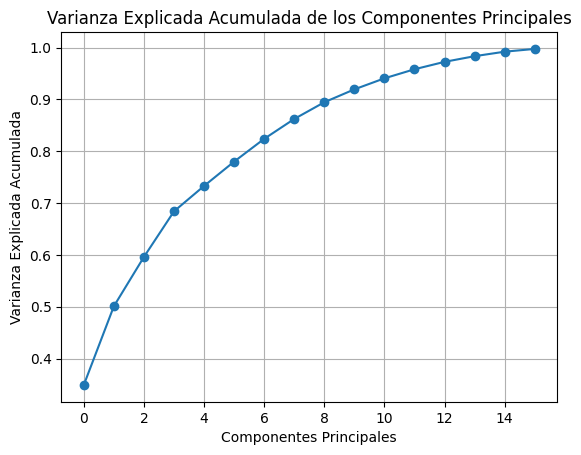

In [16]:
plt.figure(   )
plt.plot(varianza_acumulada, marker='o')
plt.xlabel('Componentes Principales')
plt.ylabel('Varianza Explicada Acumulada')
plt.title('Varianza Explicada Acumulada de los Componentes Principales')
plt.grid(True)
plt.show()

Ver como cada variable impacta en cada PCA

In [17]:
componenetes_df = pd.DataFrame(pca.components_, columns=df_seleccionado.columns, index=[f"PC{i+1}" for i in range(componentes.shape[1])])
componenetes_df

,Lot Area,Overall Qual,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,Bsmt Unf SF,Total Bsmt SF,1st Flr SF,2nd Flr SF,Gr Liv Area,Full Bath,Half Bath,Bedroom AbvGr,TotRms AbvGrd,Fireplaces,Garage Cars,Garage Area
PC1,0.122546,0.317798,0.239440,0.221111,0.218174,0.148645,0.121983,0.271077,0.274149,0.145885,0.335260,0.280453,0.144594,0.134948,0.267061,0.203932,0.304021,0.296238
PC2,-0.037086,-0.078132,-0.170239,-0.068457,-0.080263,-0.314255,0.049244,-0.294969,-0.259175,0.501096,0.229203,0.127242,0.305187,0.394887,0.318576,-0.034293,-0.092117,-0.130388
PC3,-0.361660,0.197157,0.410638,0.407039,-0.032634,-0.122439,-0.069319,-0.222182,-0.335459,0.121520,-0.165665,0.088985,0.253098,-0.264293,-0.226818,-0.179861,0.180308,0.113666
PC4,-0.130891,0.041922,0.029478,0.094615,-0.122975,-0.487820,0.688220,0.148545,0.111362,-0.176342,-0.059178,0.161286,-0.277811,0.078985,0.028600,-0.254774,-0.004265,-0.017585
PC5,0.557581,-0.104905,-0.085754,-0.136369,-0.226894,-0.280670,0.079130,-0.187002,-0.113539,0.010725,-0.080876,-0.141751,0.067120,-0.143701,-0.115413,0.090272,0.438156,0.449905
PC6,-0.189044,0.137148,-0.109633,-0.230750,0.477089,-0.231273,0.312440,0.066124,-0.013754,0.024907,0.009110,-0.367113,0.346630,-0.263824,-0.105545,0.392027,-0.058667,-0.058385
PC7,0.439805,0.130235,0.138207,0.364792,-0.330235,-0.079266,0.093485,0.023278,0.012872,0.010183,0.018325,0.078715,0.124841,-0.180606,-0.090273,0.400258,-0.348018,-0.410291
PC8,-0.505458,0.093717,-0.192589,-0.090389,-0.492555,-0.012838,-0.057595,-0.060713,0.043822,0.033654,0.069084,0.098671,-0.240735,-0.085939,0.043545,0.562756,0.158130,0.119140
PC9,-0.136265,-0.037323,0.095395,-0.049967,-0.514777,0.191695,0.131160,0.328536,0.113349,-0.088904,0.012688,-0.427417,0.518359,0.158413,0.063772,-0.191821,0.006089,0.057200
PC10,-0.024576,-0.242339,0.555526,-0.296175,0.058347,-0.083813,-0.016935,-0.074135,-0.032609,-0.272341,-0.268662,0.184470,0.108140,0.454041,-0.081981,0.340799,0.048432,-0.060232
